# SeisGeoMech — does Gardner's density prediction hold at well 48/10b-9, and what does its error cost?

**Purpose → supplied inputs → assumptions → calculations → verification → results → limitations**

---

## 1. Purpose

The seismic practical teaches you to build a synthetic seismogram when you have a velocity but
no density: you predict density from velocity with **Gardner's relation**, and carry on.
The geomechanics notes teach you that the vertical stress in the ground is the integral of that
same density, $\partial\sigma_{zz}/\partial z = \rho g$.

So a density prediction is not only a seismic convenience. It is also, silently, a stress prediction.

This project asks:

> How well does Gardner's velocity–density relation describe the **measured** interval at well
> **48/10b-9**, does a locally fitted relation predict a **separate depth interval**, and what do
> the density errors imply for the qualified $\rho g$ calculations (and for the zero-offset
> reflectivity)?

*Coursework, published in September 2026 and extended and re-verified in October 2026. The
extension adds §4.8, a two-direction depth-block test whose design was frozen before it was
scored. Every original calculation below is unchanged.*

Two things are settled up front, because every number below depends on them.

**The logged depth coordinate is not shown to be vertical.** The file's depth curve is labelled
`DEPT`, which by itself says nothing about the convention, and §2 shows there is no TVD curve, no
deviation survey, `LMF` is `UNKNOWN` and every elevation field is zero. So the absolute gradient is
reported as an explicitly one-dimensional application of the supplied model, not as a field stress
profile. The measured-versus-Gardner **difference** is invariant under *uniform* scaling of that
coordinate: both profiles are integrated over the same array, so one constant factor applied to
every interval cancels from their ratio. That is the precise claim, and §4.2 sets out its limit.
That difference is the result this notebook leads with.

**Reflection coefficients and synthetic traces are different quantities.** The RMS ratio computed
on reflection coefficients is not a synthetic-trace amplitude ratio, and §4.7 shows they disagree.
They are reported separately throughout.

That is the whole project. It is deliberately small because the supplied material supports exactly
this and no more. `SOURCE_MAP.md` gives the document, section and notebook cell behind every
equation, number and dataset used.

**What each subject contributes**

| | contribution |
|---|---|
| **Seismic** | the Gardner relation, acoustic impedance, normal-incidence reflection coefficients, the Ricker wavelet and convolution, the wavelet-frequency experiment, and the LAS file itself |
| **Models** | the overburden relation $\partial\sigma_{zz}/\partial z=\rho g$, the uniaxial-strain result $\sigma_{xx}=\tfrac{\nu}{1-\nu}\sigma_{zz}$, the link between elastic moduli and $V_p$/$V_s$, and the two worked examples (olivine, Merivale granite) that verify the elasticity code |

The link between them is real and one-directional: a seismic-side density model propagates
directly into a mechanics-side stress gradient, because they are the same $\rho$.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from seisgeomech import analysis, elasticity as el, las_io, seismic as sx, stress as st
from seisgeomech import worked_examples as wx
from seisgeomech.units import STANDARD_GRAVITY

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print("seisgeomech", __import__("seisgeomech").__version__)

seisgeomech 3.1.0


---

## 2. Supplied inputs

Everything below comes from one of the two supplied folders. Nothing else is read.

**From `Seismic/`**

* `48_10b-_9_jwl_JWL_FILE_1682139.las` — UK well 48/10b-9, operator BP, spudded 1990-08-26.
  Depth in feet, 18,975 samples, NULL = −999.25. The curves used are `DT` (sonic slowness,
  µs/ft) and `RHOB` (bulk density, g/cm³); `GR`, `NPHI`, `CALI`, `DRHO` are read for context only.
* `Ex1.ipynb` — Gardner, impedance, reflection coefficients, Ricker, convolution, resolution.
* `Unsupervised-las_answers.ipynb` — reads this LAS file with `lasio`.

**From `Models/`**

* `1_Elasticity.pdf` — isotropic elastic constants, Voigt/Reuss/Hill, $V_p$ and $V_s$.
* `Elasticity_exercise.pdf` + `Elasticity Exercise Solutions.pdf` — Q3 (olivine stiffness tensor,
  ρ = 3355 kg/m³), Q4 (Merivale granite compression record), Q5 (overburden and uniaxial strain).
* `2_Hard_rocks.pdf` — the effective stress law, and the six-stage description of a compression
  test used to pick the linear-elastic window in Q4.

Let us look at what the log actually contains.

In [2]:
log = las_io.read_las(ROOT / "data" / "raw" / "48_10b-_9_jwl_JWL_FILE_1682139.las")
print(f"{log.n_samples:,} depth samples, NULL = {log.null_value}")
log.coverage()

18,975 depth samples, NULL = -999.25


,curve,n_valid,coverage_pct,top_m,base_m
0,CALI,15232,80.2740,766.0000,"3,825.0000"
1,ILM,15381,81.0593,766.0000,"3,842.0000"
2,ILD,15381,81.0593,766.0000,"3,842.0000"
3,DT,15297,80.6166,766.0000,"3,835.0000"
4,TENS,18935,99.7892,55.2000,"3,842.0000"
5,CGR,6811,35.8946,"2,470.0000","3,832.0000"
6,DTL,6601,34.7879,"2,515.0000","3,835.0000"
7,RHOB,1180,6.2187,"3,614.2000","3,850.0000"
8,DRHO,1180,6.2187,"3,614.2000","3,850.0000"
9,PEF,1180,6.2187,"3,614.2000","3,850.0000"


This table is the single most important fact in the project.

* `DT` is logged over **3,069 m** (766 → 3,835 m).
* `RHOB` is logged over **236 m** near total depth, about **6 %** of the well.
* There is **no `DTS`** — no shear sonic. That absence decides what can and cannot be computed later.

The two curves overlap over roughly 221 m. That overlap is the only place on Earth, in this
dataset, where Gardner can be tested against a measurement.

### What the file says about its own depth convention

The overburden relation in `Models` is written for a **vertical** coordinate. Before using it, ask
the file what its depth curve actually is.

In [3]:
log.depth_convention_evidence()

,field_or_curve,meaning,value
0,LMF,LOGS MEAS FROM,UNKNOWN
1,EKB,KB ELEVATION,.0
2,EDF,ELEV DRILL FLOOR,.0
3,EPD,ELEV PERM DATUM,.0
4,EGL,GROUND LEVEL,.0
5,ELZ,ELEVATION LOG ZERO,.0
6,WDMS,WATER DEPTH,.0 M
7,TVD,true vertical depth curve,ABSENT
8,TVDSS,TVD subsea curve,ABSENT
9,DEVI,deviation / inclination curve,ABSENT


Nothing here establishes true vertical depth: `LMF` ("logs measured from") is `UNKNOWN`, every
elevation and water-depth field is zero, and there is no TVD, deviation, inclination or azimuth
curve. The only statement about depth convention anywhere in the supplied material is in
`Seismic/Unsupervised-las_answers.ipynb`, which says logs are plotted against "measure depth **or**
true vertical depth" — it names the distinction and does not resolve it for this file.

So `DEPT_M` is treated throughout as **the logged depth coordinate in metres**, and never silently
as TVD. What follows from that is set out in §4.2.

In [4]:
ov = log.overlap(("DT", "RHOB"))
ov = ov[np.isfinite(ov["VP"]) & (ov["VP"] > 0)].reset_index(drop=True)
print(f"overlap: {len(ov)} samples, {ov.DEPT_M.min():.1f} - {ov.DEPT_M.max():.1f} m "
      f"({ov.DEPT_M.max() - ov.DEPT_M.min():.1f} m)")
ov[["DEPT_M", "DT", "VP", "RHOB", "GR", "NPHI", "CALI", "DRHO"]].describe().T

overlap: 1105 samples, 3614.2 - 3835.0 m (220.8 m)


,count,mean,std,min,25%,50%,75%,max
DEPT_M,"1,105.0000","3,724.6000",63.8261,"3,614.2000","3,669.4000","3,724.6000","3,779.8000","3,835.0000"
DT,"1,105.0000",67.3097,6.6307,55.3362,62.5775,65.4186,70.8875,89.7690
VP,"1,105.0000","4,569.2136",418.0410,"3,395.3815","4,299.7708","4,659.2254","4,870.7603","5,508.1484"
RHOB,"1,105.0000",2.6398,0.1067,2.2813,2.5649,2.6888,2.7197,2.7986
GR,"1,105.0000",65.5518,27.8509,17.6415,39.1356,67.1787,85.7539,196.7695
NPHI,"1,105.0000",0.1301,0.0451,0.0110,0.0994,0.1217,0.1553,0.2653
CALI,"1,055.0000",8.4152,0.1097,8.2660,8.2969,8.4375,8.4453,9.3679
DRHO,"1,105.0000",0.0010,0.0199,-0.0264,-0.0085,-0.0043,0.0020,0.1540


---

## 3. Assumptions

Kept short on purpose. Each is either a unit definition, a defined constant, or a statement about
what is *not* assumed.

1. **Feet to metres, 0.3048 exactly.** A unit definition, needed to read the file.
2. **$V_p = 10^6 \times 0.3048 / DT$.** This is the definition of the logged unit µs/ft, not a
   rock-physics model.
3. **$g = 9.80665\ \mathrm{m\,s^{-2}}$.** Q5 writes $g$ symbolically and gives no number, so the
   defined SI value of standard gravity is used. It is a universal constant, not a rock property.
4. **Gardner's coefficients are used exactly as written in `Ex1.ipynb`:** $\rho = 0.31\,V_p^{0.25}$.
   The notebook does not state the units. The only convention under which it returns sensible bulk
   densities is $V_p$ in m/s giving $\rho$ in g/cm³, and section 7 confirms that against measurement.
5. **No QC cut-off is applied.** Only the header NULL value is rejected. `CALI` and `DRHO` are
   reported so you can judge hole condition, but the supplied material states no threshold for
   either, so applying one would be an imported convention.
6. **Total stress only.** No pore pressure is measured anywhere in the supplied data, and the LAS
   header records no mud weight (`DFD` is 0.000), so no effective stress is computed. The effective
   stress law is implemented (`stress.effective_stress`) and deliberately never called.
7. **Isotropy and linear elasticity**, as stated throughout `1_Elasticity.pdf`.
8. **The logged coordinate is used as supplied.** No trajectory is obtained, invented or assumed.
   Where the supplied overburden model needs a vertical coordinate, the calculation is presented as
   an explicitly one-dimensional application of that model and labelled as such.

**Not assumed anywhere:** no lithology, no mineral or matrix density, no porosity, no shear
velocity, no $V_p$–$V_s$ relation, no dynamic-to-static correction, no friction coefficient, no
cohesion, no Biot coefficient, no thermal expansion, no quarter-wavelength tuning rule, no
geothermal gradient, no external property table.

---

## 4. Calculations

### 4.1 Velocity, and Gardner against the measured density

In [5]:
vp = ov["VP"].to_numpy()             # m/s
rhob = ov["RHOB"].to_numpy()          # g/cm^3, measured
rho_gardner = sx.gardner_density_gcc(vp)   # g/cm^3, predicted from Vp

residual = rho_gardner - rhob
print(f"measured mean  {rhob.mean():.4f} g/cm3")
print(f"Gardner  mean  {rho_gardner.mean():.4f} g/cm3")
print(f"bias           {residual.mean():+.4f} g/cm3  ({100*residual.mean()/rhob.mean():+.2f} %)")
print(f"RMSE           {np.sqrt((residual**2).mean()):.4f} g/cm3")
print(f"sd of residual {residual.std(ddof=1):.4f} g/cm3")
print(f"corr(Vp, RHOB) {np.corrcoef(vp, rhob)[0,1]:.4f}")

measured mean  2.6398 g/cm3
Gardner  mean  2.5466 g/cm3
bias           -0.0932 g/cm3  (-3.53 %)
RMSE           0.1179 g/cm3
sd of residual 0.0723 g/cm3
corr(Vp, RHOB) 0.7576


Gardner **under-predicts** density here by about 0.09 g/cm³, a systematic 3.5 %, with a scatter of
0.07 g/cm³ on top. Velocity does carry real density information — the two correlate at 0.76 — but
the published coefficients are not right for this well.

It is worth asking what coefficients *would* fit these points. This changes no equation: it fits
the same functional form to the same 1,105 samples.

Read the next cell as an **in-sample calibration** and nothing more. No samples were held out; the
coefficients were fitted and evaluated on the same 1,105 paired samples, so the drop in RMSE is a
descriptive fit statistic on the calibration data. It is not evidence of predictive skill at other
depths or other wells, and it does not establish that the functional form is right and only its
coefficients wrong.

Whether coefficients fitted on part of the interval *predict* another part is a separate
question, answered in §4.8 with a split fixed in advance.

In [6]:
b, log_a = np.polyfit(np.log(vp), np.log(rhob), 1)
a = np.exp(log_a)
rho_refit = a * vp ** b
rmse_supplied = np.sqrt(((rho_gardner - rhob) ** 2).mean())
rmse_refit = np.sqrt(((rho_refit - rhob) ** 2).mean())
print(f"supplied coefficients : rho = 0.310 * Vp^0.250   RMSE {rmse_supplied:.4f} g/cm3")
print(f"refitted on these data: rho = {a:.3f} * Vp^{b:.3f}   RMSE {rmse_refit:.4f} g/cm3")
print(f"\nIN-SAMPLE: no samples were held out; the coefficients were fitted and")
print(f"evaluated on the same {len(vp):,} paired samples.")
print(f"RMSE reduction on the calibration data: {100*(rmse_supplied-rmse_refit)/rmse_supplied:.1f} %")
print("This describes these points; it is not a prediction test.")

supplied coefficients : rho = 0.310 * Vp^0.250   RMSE 0.1179 g/cm3
refitted on these data: rho = 0.159 * Vp^0.333   RMSE 0.0690 g/cm3

IN-SAMPLE: no samples were held out; the coefficients were fitted and
evaluated on the same 1,105 paired samples.
RMSE reduction on the calibration data: 41.5 %
This describes these points; it is not a prediction test.


### 4.2 What the density error does to the $\rho g$ gradient

`Models/Elasticity_exercise.pdf` Q5: $\partial\sigma_{zz}/\partial z = \rho g$, integrated with
$z$ increasing downwards and compression positive.

Three things are **not** computed here, and it is worth being exact about each.

* **Not an absolute $\sigma_{zz}$.** That would need the density of everything above 3,614 m, which
  is not logged. What is computed is the integral across the interval and the mean gradient, both
  independent of any depth datum.
* **Not a verified vertical stress.** Q5's $z$ is vertical; the logged coordinate is not shown to be
  (§2). The absolute gradients below are therefore a one-dimensional application of the supplied
  model to the logged coordinate — a defensible way to use the equation, but not a field stress
  profile, and the notebook does not call it one.
* **Invariant under uniform coordinate scaling, for the comparison.** The measured and Gardner
  densities are integrated over the *same* coordinate array, so multiplying every interval by one
  constant factor rescales both integrals identically and cancels from their ratio. That is why the
  difference, not the absolute value, is the headline — and it is the precise claim, not a general
  independence from geometry. It does **not** extend to a depth-dependent trajectory correction,
  which would reweight the two integrals sample by sample; since the Gardner density is not a
  constant multiple of the measured density, such a correction would in general change the ratio.
  No trajectory correction is applied, and the gradient calculations keep their one-dimensional
  qualification. §5.3 checks both the invariance and its limit.

In [7]:
z = ov["DEPT_M"].to_numpy()          # logged depth coordinate, metres
rho_m_si = rhob * 1000.0
rho_g_si = rho_gardner * 1000.0

inc_m = st.rho_g_integral(z, rho_m_si)
inc_g = st.rho_g_integral(z, rho_g_si)
grad_m = st.mean_rho_g_gradient(z, rho_m_si)
grad_g = st.mean_rho_g_gradient(z, rho_g_si)

print("one-dimensional application of Models Q5 to the logged coordinate:")
print(f"  measured density : gradient {grad_m/1e3:7.3f} MPa/km, integral {inc_m[-1]/1e6:.3f} MPa over {z[-1]-z[0]:.1f} m")
print(f"  Gardner  density : gradient {grad_g/1e3:7.3f} MPa/km, integral {inc_g[-1]/1e6:.3f} MPa")
print()
print("comparison, invariant under uniform scaling of the logged coordinate:")
print(f"  difference       : {(grad_g-grad_m)/1e3:+.3f} MPa/km  ({100*(grad_g-grad_m)/grad_m:+.2f} %)")
print(f"  which equals the density bias of {100*(rho_gardner-rhob).mean()/rhob.mean():+.2f} %, as it must")

one-dimensional application of Models Q5 to the logged coordinate:
  measured density : gradient  25.887 MPa/km, integral 5.716 MPa over 220.8 m
  Gardner  density : gradient  24.973 MPa/km, integral 5.514 MPa

comparison, invariant under uniform scaling of the logged coordinate:
  difference       : -0.914 MPa/km  (-3.53 %)
  which equals the density bias of -3.53 %, as it must


The gradient is linear in density, so the 3.5 % density bias reappears exactly as a 3.5 % gradient
difference — 0.91 MPa per kilometre. That identity is worth pausing on: it is the reason a density
prediction made for a seismic purpose is also, unavoidably, a statement about stress.

No extrapolation beyond the logged interval is offered. The bias is measured over 221 m near total
depth, and this dataset gives no way to know whether it holds shallower.

### 4.3 The horizontal stress — and why it stops here

Q5 also gives the gravitational horizontal stress under no lateral strain:

$$\sigma_{xx} = \frac{\nu}{1-\nu}\,\sigma_{zz}$$

with the accompanying vertical strain $\varepsilon_{zz} = \dfrac{\sigma_{zz}}{E}\left(1 - \dfrac{2\nu^2}{1-\nu}\right)$,
and the state is hydrostatic only when $\nu = \tfrac12$.

To evaluate this at the well you need $\nu$. Poisson's ratio for an isotropic solid follows from
$V_p$ **and** $V_s$ — and this well has no shear sonic. So the relation is shown parametrically,
and no value is claimed for 48/10b-9. This is the clean statement of what one extra measurement
would buy.

In [8]:
nus = np.array([0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50])
pd.DataFrame({
    "Poisson's ratio": nus,
    "sigma_h / sigma_v": st.horizontal_over_vertical_ratio(nus),
    "implied sigma_h gradient (MPa/km)": st.horizontal_over_vertical_ratio(nus) * grad_m / 1e3,
})

,Poisson's ratio,sigma_h / sigma_v,implied sigma_h gradient (MPa/km)
0,0.0500,0.0526,1.3625
1,0.1000,0.1111,2.8764
2,0.1500,0.1765,4.5684
3,0.2000,0.2500,6.4718
4,0.2500,0.3333,8.6291
5,0.3000,0.4286,11.0946
6,0.3500,0.5385,13.9393
7,0.4000,0.6667,17.2582
8,0.4500,0.8182,21.1805
9,0.5000,1.0000,25.8873


### 4.4 What elasticity *can* be recovered from the log

`1_Elasticity.pdf` s.10 gives $V_p = \sqrt{(K + \tfrac43 G)/\rho}$. Rearranged, a sonic and a
density log give the combination

$$M = \rho V_p^2 = K + \tfrac43 G$$

and nothing more. $K$ and $G$ cannot be separated without $V_s$. $M$ is still a genuine stiffness
profile, and it is the only elastic modulus this well supports.

P-wave modulus over the overlap: 28.0 - 83.1 GPa, mean 55.9 GPa


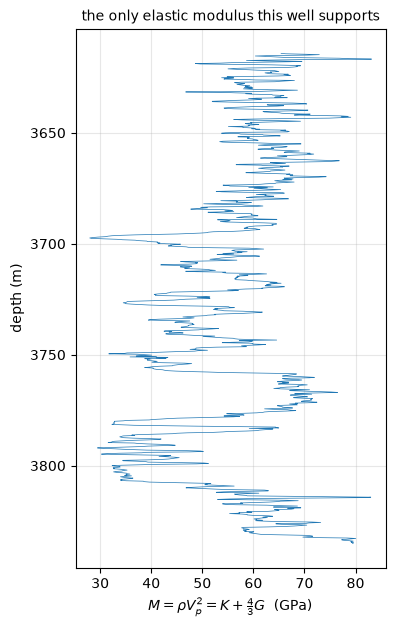

In [9]:
M = el.p_wave_modulus_from_vp_rho(vp, rho_m_si)
print(f"P-wave modulus over the overlap: {M.min()/1e9:.1f} - {M.max()/1e9:.1f} GPa, mean {M.mean()/1e9:.1f} GPa")

fig, ax = plt.subplots(figsize=(4, 7))
ax.plot(M / 1e9, z, lw=0.5)
ax.invert_yaxis(); ax.grid(alpha=0.3)
ax.set_xlabel(r"$M = \rho V_p^2 = K + \frac{4}{3}G$  (GPa)")
ax.set_ylabel("depth (m)")
ax.set_title("the only elastic modulus this well supports", fontsize=10)
plt.show()

### 4.5 Impedance, reflectivity, and the same error seen seismically

`Ex1.ipynb` s.1.3 and s.1.4:

$$Z = \rho V_p \qquad\qquad R_i = \frac{Z_{i+1}-Z_i}{Z_{i+1}+Z_i}$$

There is a neat consequence of substituting Gardner. With $\rho = 0.31 V_p^{0.25}$,

$$Z_{\text{Gardner}} = 0.31\,V_p^{1.25}$$

so the impedance — and therefore every reflection coefficient — becomes a function of **velocity
alone**. Any impedance contrast that comes from a density change independent of velocity simply
disappears, and velocity contrasts are raised to the power 1.25 instead of 1.

In [10]:
Z_m = sx.acoustic_impedance(rho_m_si, vp)
Z_g = sx.acoustic_impedance(rho_g_si, vp)
rc_m = sx.reflection_coefficients(Z_m)
rc_g = sx.reflection_coefficients(Z_g)

print("reflection coefficients, BEFORE wavelet convolution:")
print(f"RC rms   measured {np.sqrt((rc_m**2).mean()):.5f}   Gardner {np.sqrt((rc_g**2).mean()):.5f}")
print(f"RC max   measured {np.abs(rc_m).max():.4f}     Gardner {np.abs(rc_g).max():.4f}")
print(f"ratio of rms amplitudes : {np.sqrt((rc_g**2).mean())/np.sqrt((rc_m**2).mean()):.3f}")
print(f"correlation             : {np.corrcoef(rc_m, rc_g)[0,1]:.4f}")

# the closed form, as an independent check
closed = (vp[1:]**1.25 - vp[:-1]**1.25) / (vp[1:]**1.25 + vp[:-1]**1.25)
print(f"\nclosed-form check, max |difference| = {np.abs(closed - rc_g).max():.2e}")

reflection coefficients, BEFORE wavelet convolution:
RC rms   measured 0.01282   Gardner 0.01541
RC max   measured 0.0634     Gardner 0.0827
ratio of rms amplitudes : 1.202
correlation             : 0.9348

closed-form check, max |difference| = 2.72e-16


So Gardner keeps the **pattern** of the reflection-coefficient series (correlation 0.93) while
raising its RMS by about 20 %.

Be precise about what that 1.20 describes: it is a ratio of **reflection coefficients, before any
wavelet is applied**. It is not a synthetic-trace amplitude ratio, and §4.7 shows that once a
wavelet is convolved the ratio is below one at every frequency tested. No field seismic data are
used anywhere in this project, so nothing here says anything about calibrating a synthetic against
a real seismic amplitude.

### 4.6 Travel time along the logged path

A Ricker wavelet has a frequency in hertz, so the convolution belongs on a time axis. The sonic log
is itself a travel time per unit length, so integrating it along the logged coordinate gives
one-way time along that path directly:

$$t_{\text{ow}}(s) = \int DT\,\mathrm{d}s, \qquad t = 2\,t_{\text{ow}}$$

This is arithmetic on the logged unit, not a velocity model. It is **travel time along the logged
path, not vertical two-way time** — the coordinate is not shown to be vertical (§2), and no
checkshot, datum or drift correction is supplied. Its only job here is to put the reflectivity on a
regular time axis so a wavelet specified in hertz can be convolved with it. This is not a
seismic-to-well tie; no field seismic data are involved.

In [11]:
twt = sx.two_way_travel_time_along_log(z, ov["DT"].to_numpy())
print(f"interval spans {twt[-1]*1e3:.2f} ms of two-way travel time along the logged path")

dt_s = 1e-4  # 0.1 ms regular sampling
t_mid = 0.5 * (twt[1:] + twt[:-1])
t_reg, rc_m_t = sx.resample_to_regular_time(t_mid, rc_m, dt_s)
_,     rc_g_t = sx.resample_to_regular_time(t_mid, rc_g, dt_s)

f_min = sx.min_supportable_frequency(rc_m_t.size, dt_s)
print(f"trace is {rc_m_t.size} samples; a Ricker below {f_min:.1f} Hz would be longer than the whole trace")

interval spans 97.53 ms of two-way travel time along the logged path
trace is 975 samples; a Ricker below 20.5 Hz would be longer than the whole trace


### 4.7 The wavelet-frequency experiment

`Ex1.ipynb` poses this as a question rather than a formula: *change the wavelet frequency and see
how the convolved trace compares with the reflection-coefficient series.* No quarter-wavelength or
tuning rule is given in the supplied material, so none is used here. Instead the comparison is made
directly — convolve, then measure two separate things about the result.

**How to read the correlation.** It is the Pearson correlation between the synthetic trace and the
reflectivity series that produced it: a linear-similarity measure between two specific series in
this synthetic experiment. It is **not** the fraction of the log's information, variability or
structure that has been recovered, and neither is its square — the comparison is between a
broadband input and a band-limited output of that same input, so the number is not a decomposition
of anything. It is useful for ranking frequencies against each other inside this experiment, and
for nothing else. It is not converted into a resolvable bed thickness, and it supports no claim
about what a field survey would or would not image.

**And a separate quantity.** The RMS ratio of §4.5 was measured on reflection coefficients. The
table below also reports the RMS of the synthetic traces themselves, so the two can be compared
rather than conflated.

In [12]:
freqs = (25.0, 30.0, 40.0, 50.0, 75.0, 100.0, 150.0, 200.0, 300.0)
rows = []
for f, c_m, n, rms_m in sx.resolution_sweep(rc_m_t, dt_s, freqs):
    _, c_g, _, rms_g = sx.resolution_sweep(rc_g_t, dt_s, (f,))[0]
    rows.append({"frequency_Hz": f, "wavelet_samples": n,
                 "Pearson r, measured": c_m, "Pearson r, Gardner": c_g,
                 "synthetic RMS, measured": rms_m, "synthetic RMS, Gardner": rms_g,
                 "synthetic RMS ratio G/M": rms_g / rms_m})
sweep = pd.DataFrame(rows)
sweep

,frequency_Hz,wavelet_samples,"Pearson r, measured","Pearson r, Gardner","synthetic RMS, measured","synthetic RMS, Gardner",synthetic RMS ratio G/M
0,25.0000,801,0.0658,0.0532,0.0867,0.0859,0.9910
1,30.0000,667,0.0712,0.0567,0.0861,0.0832,0.9672
2,40.0000,501,0.0874,0.0686,0.0756,0.0701,0.9271
3,50.0000,401,0.1107,0.0862,0.0686,0.0624,0.9095
4,75.0000,267,0.1614,0.1211,0.0669,0.0605,0.9038
5,100.0000,201,0.2240,0.1666,0.0689,0.0612,0.8875
6,150.0000,133,0.2941,0.2240,0.0705,0.0623,0.8841
7,200.0000,101,0.3654,0.2839,0.0640,0.0580,0.9059
8,300.0000,67,0.4470,0.3720,0.0542,0.0513,0.9471


In [13]:
rc_ratio = np.sqrt((rc_g**2).mean()) / np.sqrt((rc_m**2).mean())
syn_ratio = sweep["synthetic RMS ratio G/M"]
print("Two different quantities, often confused:")
print(f"  reflection coefficients, before convolution : Gardner / measured = {rc_ratio:.4f}")
print(f"  synthetic traces, after convolution         : {syn_ratio.min():.4f} to {syn_ratio.max():.4f}")
print()
print("The pre-convolution ratio is above one; every post-convolution ratio is below one.")
print("The 1.20 figure therefore says nothing about synthetic trace amplitude.")

Two different quantities, often confused:
  reflection coefficients, before convolution : Gardner / measured = 1.2017
  synthetic traces, after convolution         : 0.8841 to 0.9910

The pre-convolution ratio is above one; every post-convolution ratio is below one.
The 1.20 figure therefore says nothing about synthetic trace amplitude.


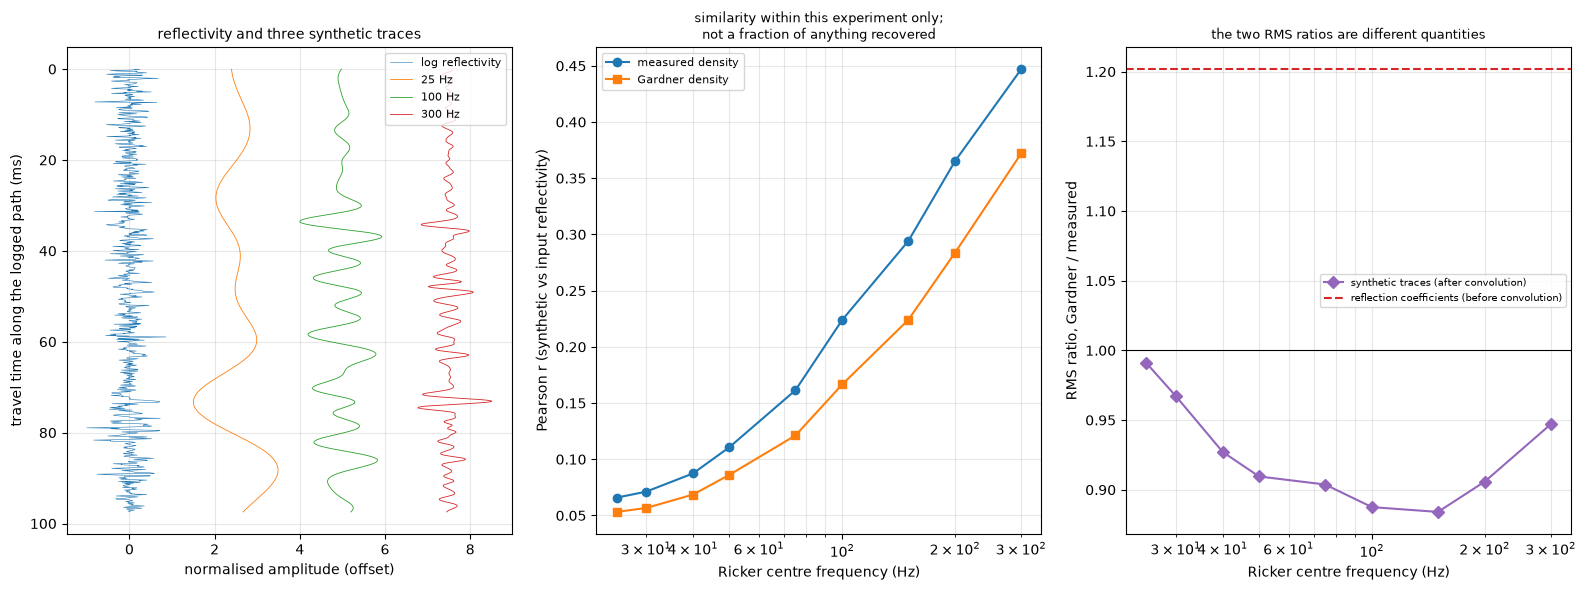

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(16, 6))
t_ms = t_reg * 1e3
ax[0].plot(rc_m_t / np.abs(rc_m_t).max(), t_ms, lw=0.4, label="log reflectivity")
for k, f in enumerate((25.0, 100.0, 300.0), start=1):
    w, _ = sx.ricker_wavelet(2.0 / f, dt_s, f)
    s = sx.convolve_trace(rc_m_t, w)
    ax[0].plot(s / np.abs(s).max() + 2.5 * k, t_ms, lw=0.6, label=f"{f:.0f} Hz")
ax[0].invert_yaxis(); ax[0].grid(alpha=0.3); ax[0].legend(fontsize=8)
ax[0].set_xlabel("normalised amplitude (offset)")
ax[0].set_ylabel("travel time along the logged path (ms)")
ax[0].set_title("reflectivity and three synthetic traces", fontsize=10)

ax[1].plot(sweep.frequency_Hz, sweep["Pearson r, measured"], "o-", label="measured density")
ax[1].plot(sweep.frequency_Hz, sweep["Pearson r, Gardner"], "s-", label="Gardner density")
ax[1].set_xscale("log"); ax[1].grid(alpha=0.3, which="both"); ax[1].legend(fontsize=8)
ax[1].set_xlabel("Ricker centre frequency (Hz)")
ax[1].set_ylabel("Pearson r (synthetic vs input reflectivity)")
ax[1].set_title("similarity within this experiment only;\nnot a fraction of anything recovered", fontsize=9)

ax[2].plot(sweep.frequency_Hz, syn_ratio, "D-", color="tab:purple",
           label="synthetic traces (after convolution)")
ax[2].axhline(rc_ratio, color="tab:red", ls="--",
              label="reflection coefficients (before convolution)")
ax[2].axhline(1.0, color="k", lw=0.8)
ax[2].set_xscale("log"); ax[2].grid(alpha=0.3, which="both"); ax[2].legend(fontsize=7)
ax[2].set_xlabel("Ricker centre frequency (Hz)")
ax[2].set_ylabel("RMS ratio, Gardner / measured")
ax[2].set_title("the two RMS ratios are different quantities", fontsize=9)
plt.tight_layout(); plt.show()

Two things can be said from this table, and it is worth being strict about the boundary.

**What it shows.** Within this synthetic experiment, the correlation between the trace and its own
input reflectivity rises monotonically with Ricker centre frequency across the tested range, and
the Gardner-density curve sits slightly below the measured-density curve at every frequency. The
synthetic-trace RMS ratio stays between 0.88 and 0.99 — below one at every frequency — while the
pre-convolution reflection-coefficient ratio was 1.20. Those are different quantities and behave
differently.

**What it does not show.** The correlation is not a percentage of information, variability or
structure recovered, and squaring it does not make it one. Nothing here establishes which layering
a field seismic survey could or could not image: no field data were used, no frequency here is
claimed to be representative of a real survey, and the supplied material provides no
quarter-wavelength or tuning rule that would convert any of these numbers into a bed thickness.


### 4.8 Does a locally fitted relation predict a separate depth interval? (October 2026)

The refit in §4.1 was scored on the samples it was fitted to. Validation on another well is not
possible: the supplied material has paired sonic and density logs for this one well only. A
within-well test is: fit the same form, with the same method, on one contiguous block of the
interval and predict the other.

The design is in `configs/depth_blocks.json`. It was committed, with the split below, before any
held-out prediction was computed:

* the 1,105 paired samples, sorted by the logged coordinate;
* a 20 m gap centred on the interval's midpoint, so block **A** lies above it and block **B** below;
* fit on A and predict B, then fit on B and predict A;
* each prediction compared with the supplied `0.31 Vp^0.25` on exactly the same samples;
* the reading rule. The block fit is *better* only if both its held-out RMSE and its MAE are lower,
  *worse* only if both are higher, and *mixed* otherwise. The two directions are never pooled.

The gap is a design choice. It follows an earlier estimate of how far the residuals stay
correlated, it does not make the blocks independent, and it is measured along the logged
coordinate, not in vertical depth.

In [15]:
from seisgeomech import depth_blocks as db

cfg = db.load_config(ROOT / "configs" / "depth_blocks.json")
record, labelled = db.derive_split(db.paired_samples(log), cfg)
db.check_frozen(record, cfg)     # raises unless this is exactly the frozen split
print("design:", cfg["status"])
for name in ("A", "excluded", "B"):
    b = record["blocks"][name]
    print(f"  {name:9s} n = {b['n']:4d}   {b['depth_m_first']:8.2f} - {b['depth_m_last']:8.2f} m   "
          f"Vp {b['vp_min_m_s']:5.0f} - {b['vp_max_m_s']:5.0f} m/s")
print(f"  last A sample to first B sample: {record['separation_last_A_to_first_B_m']:.1f} m "
      "along the logged coordinate")

design: frozen: committed with the derived split before any held-out prediction was scored
  A         n =  502    3614.20 -  3714.40 m   Vp  3395 -  5508 m/s
  excluded  n =  100    3714.60 -  3734.40 m   Vp  3797 -  4968 m/s
  B         n =  503    3734.60 -  3835.00 m   Vp  3497 -  5505 m/s
  last A sample to first B sample: 20.2 m along the logged coordinate


In [16]:
scores, pred = db.score(labelled, record, cfg)
rows = []
for name, d in scores["directions"].items():
    h, s = d["held_out_block_fit"], d["held_out_supplied_gardner"]
    g = d["rho_g_gradient_over_evaluation_block"]
    rows.append((name.replace("_to_", " -> "),
                 f"{d['fitted_coefficient_a']:.4f} Vp^{d['fitted_exponent_b']:.4f}", h["n"],
                 h["bias_gcc"], h["rmse_gcc"], h["mae_gcc"], s["bias_gcc"], s["rmse_gcc"], s["mae_gcc"],
                 g["block_fit_minus_measured_MPa_per_km"], g["supplied_minus_measured_MPa_per_km"],
                 d["reading"]))
held_out = pd.DataFrame(rows, columns=[
    "direction", "fitted on training block", "n",
    "block fit: bias", "RMSE", "MAE", "supplied: bias", "supplied RMSE", "supplied MAE",
    "rho g error, block fit (MPa/km, 1-D)", "rho g error, supplied (MPa/km, 1-D)", "reading"])
print("overall reading (frozen rule):", scores["overall_reading"])
held_out.style.hide(axis="index")

overall reading (frozen rule): block fit better


direction,fitted on training block,n,block fit: bias,RMSE,MAE,supplied: bias,supplied RMSE,supplied MAE,"rho g error, block fit (MPa/km, 1-D)","rho g error, supplied (MPa/km, 1-D)",reading
A -> B,0.2362 Vp^0.2875,503,0.036096,0.088337,0.068818,-0.076379,0.112677,0.091682,0.352620,-0.750201,block fit better
B -> A,0.1859 Vp^0.3143,502,-0.034905,0.061039,0.050337,-0.119259,0.129422,0.120397,-0.342408,-1.169550,block fit better


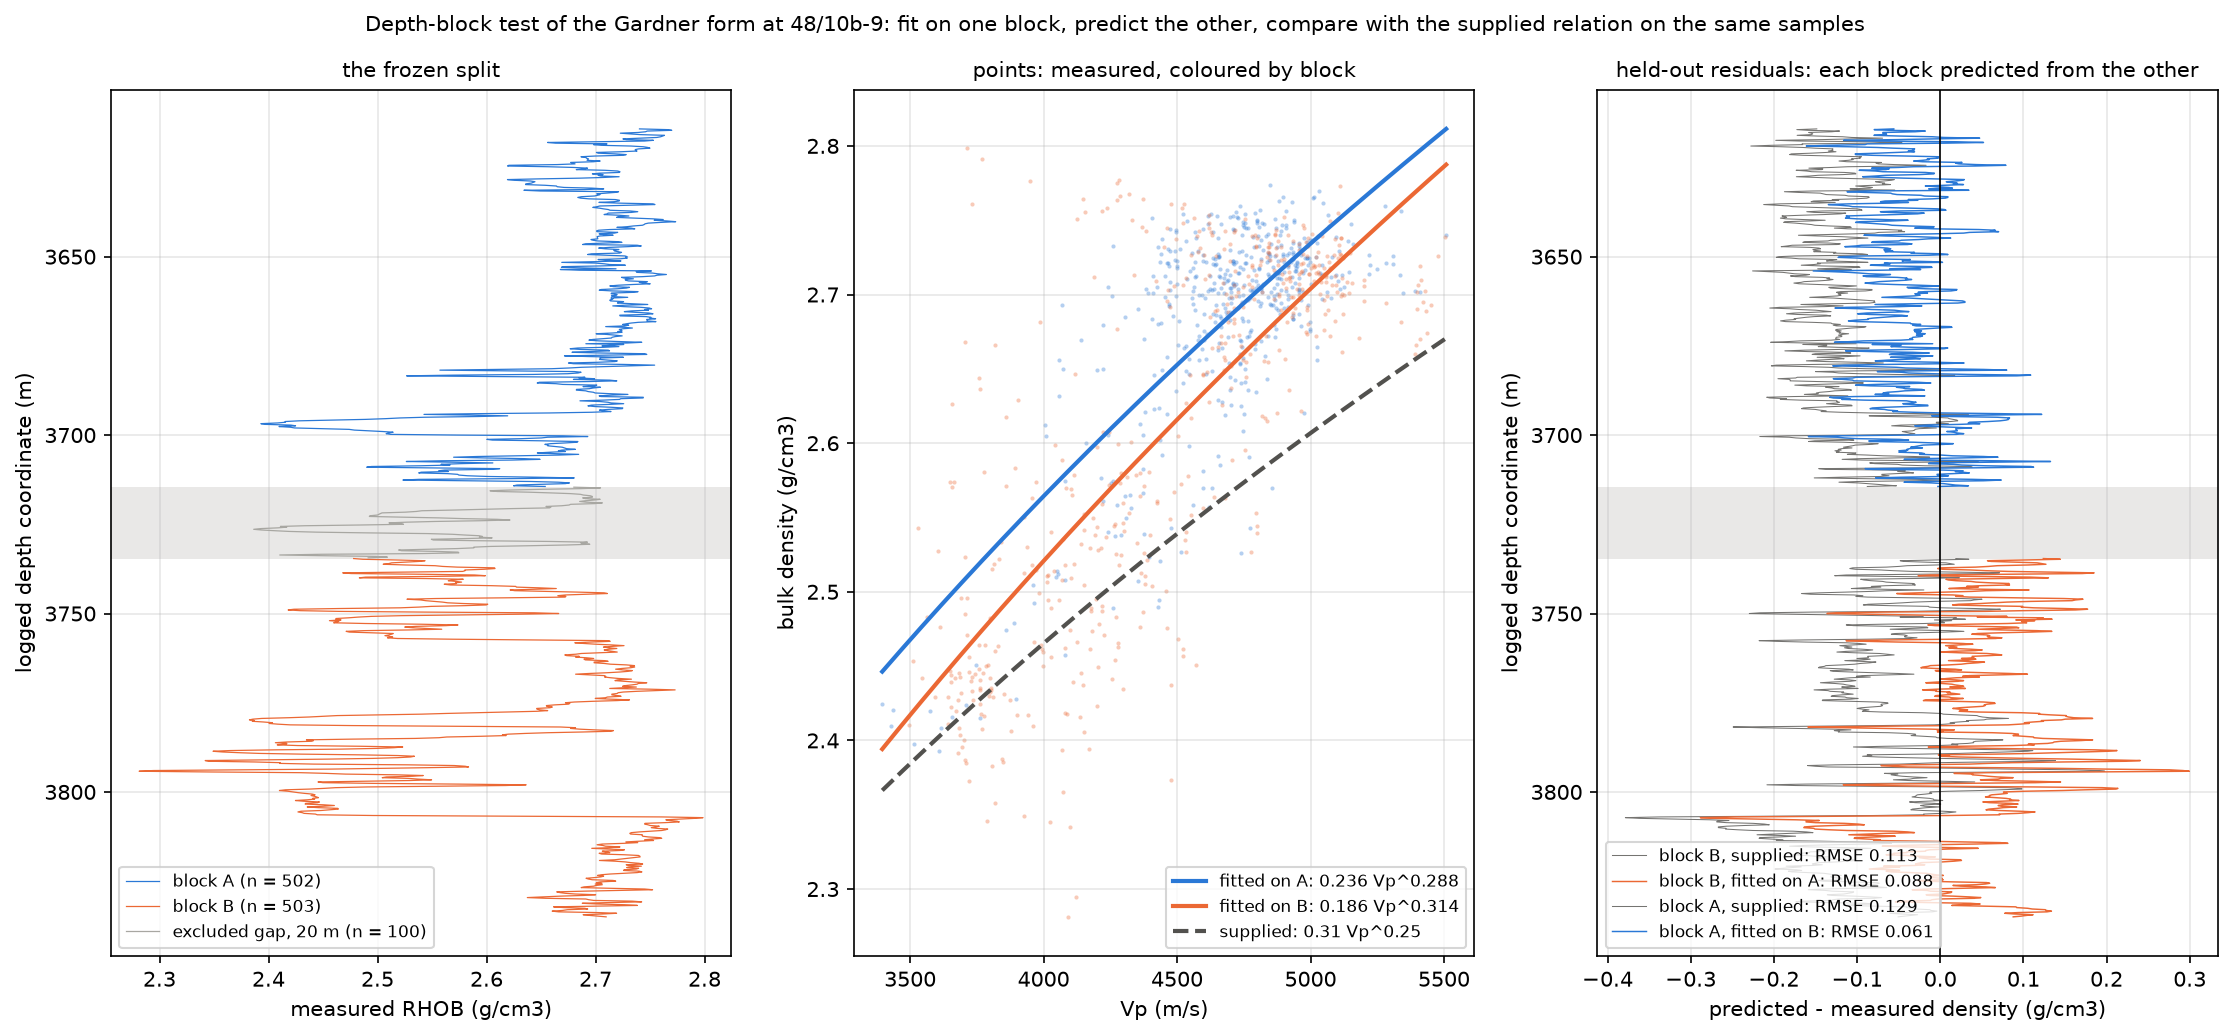

,lag_m,lag_samples,pairs,supplied_gardner_residual,in_sample_refit_residual
0,0.2000,1,1104,0.9182,0.8850
1,1.0000,5,1100,0.4824,0.2865
2,2.0000,10,1095,0.4207,0.2506
3,5.0000,25,1080,0.3407,0.2352
4,10.0000,50,1055,0.2479,0.1699
5,20.0000,100,1005,0.0754,0.1035
6,30.0000,150,955,0.0171,0.0347
7,40.0000,200,905,0.1402,0.1153


In [17]:
import tempfile
from IPython.display import Image, display
from seisgeomech import figures

with tempfile.TemporaryDirectory() as tmp:
    png = figures.fig_depth_blocks({"labelled": labelled, "split": record,
                                    "scores": scores, "predictions": pred}, tmp)
    display(Image(filename=str(png)))
# context only, computed after the gap was fixed: residual correlation along the log
pd.DataFrame(scores["residual_lag_correlation"])

**What it shows.** In both directions, coefficients fitted on one block predict the other
block better than the supplied coefficients do, on exactly the same samples. Most of the gain is
the removal of the supplied relation's bias, and the ρg error over the predicted block shrinks
with it.

**What it does not show.**
* The two blocks are not described by the same coefficients. Each block fit misses the other
  block by a few hundredths of a g/cm³, with opposite signs in the two directions, so a
  calibration from one part of the interval carries a bias to the next.
* The held-out error depends on which block is predicted. Block B is more scattered than A.
* The residuals are still correlated across the 20 m gap (table above), so the blocks are not
  independent samples, and two directions give two numbers, not a distribution.
* Both relations share the functional form, so a better transfer of fitted coefficients is not
  evidence that the form is right. Nothing here extends beyond this well and interval.

The ρg errors are, as everywhere in this notebook, a one-dimensional application along the logged
coordinate.

---

## 5. Verification

Three kinds of check: against the course's own worked examples, against analytical identities, and
against internal consistency.

### 5.1 Q3 — olivine

The exercise supplies the stiffness tensor and ρ = 3355 kg/m³ and asks for the Voigt, Reuss and VRH
averages and the resulting velocities, with the check *"does this fit with the velocity at the Moho?"*

In [18]:
ol = wx.solve_olivine()
print(f"K   Voigt {ol.K_voigt_GPa:7.3f}   Reuss {ol.K_reuss_GPa:7.3f}   VRH {ol.K_hill_GPa:7.3f} GPa")
print(f"G   Voigt {ol.G_voigt_GPa:7.3f}   Reuss {ol.G_reuss_GPa:7.3f}   VRH {ol.G_hill_GPa:7.3f} GPa")
print(f"Vp  {ol.vp_m_s:.1f} m/s     Vs {ol.vs_m_s:.1f} m/s     Vp/Vs {ol.vp_vs:.3f}")
assert ol.K_reuss_GPa <= ol.K_hill_GPa <= ol.K_voigt_GPa
assert ol.G_reuss_GPa <= ol.G_hill_GPa <= ol.G_voigt_GPa
print("\nVoigt/Reuss bounds correctly ordered.")

K   Voigt 131.511   Reuss 127.390   VRH 129.451 GPa
G   Voigt  79.497   Reuss  76.441   VRH  77.969 GPa
Vp  8340.9 m/s     Vs 4820.8 m/s     Vp/Vs 1.730

Voigt/Reuss bounds correctly ordered.


**On the exercise's closing question.** Q3 asks *"does this fit with the velocity at the Moho?"*
The calculation gives Vp = 8.34 km/s and Vs = 4.82 km/s for an isotropically averaged pure olivine
aggregate. The supplied material does not quote a Moho velocity anywhere, so this project does not
assert the comparison — it is recorded as an open source gap in `SOURCE_MAP.md` s.7. What *is*
checked is internal consistency: the Hill velocities lie strictly between the velocities implied by
the Voigt and Reuss bounds, and both bounds are correctly ordered.

### 5.2 Q4 — Merivale granite

The record is a 16-point uniaxial compression test on a 15 mm × 40 mm cylinder of mass 18.73 g.
The exercise says "identify the linear portion". That choice is made with a criterion from the
notes rather than by eye: `2_Hard_rocks.pdf` s.3 places stage I (crack closure) at the lowest
stresses and starts stage III (crack propagation) "at about half the ultimate failure strength",
so the fit uses points above the first loading step and below half the peak stress.

In [19]:
mv = wx.solve_merivale()
print(f"peak stress {mv.peak_stress_MPa:.2f} MPa   ->  fit window {mv.stress_window_MPa[0]:.1f} - {mv.stress_window_MPa[1]:.1f} MPa ({mv.n_points} points)")
print(f"E   {mv.E_Pa/1e9:6.2f} GPa   (R2 = {mv.E_r2:.5f})")
print(f"nu  {mv.nu:6.4f}        (R2 = {mv.nu_r2:.5f})")
print(f"K   {mv.K_Pa/1e9:6.2f} GPa    G {mv.G_Pa/1e9:6.2f} GPa    rho {mv.rho_kg_m3:.1f} kg/m3")
print(f"Vp  {mv.vp_m_s:6.0f} m/s    Vs {mv.vs_m_s:.0f} m/s    Vp/Vs {mv.vp_vs:.3f}")

peak stress 233.85 MPa   ->  fit window 12.2 - 116.9 MPa (5 points)
E    99.95 GPa   (R2 = 0.99739)
nu  0.2534        (R2 = 0.96612)
K    67.56 GPa    G  39.87 GPa    rho 2649.8 kg/m3
Vp    6750 m/s    Vs 3879 m/s    Vp/Vs 1.740


In [20]:
# the supplied volumetric-strain column must equal axial + 2 x circumferential
resid = wx.MERIVALE_VOLUMETRIC_STRAIN - (wx.MERIVALE_AXIAL_STRAIN + 2*wx.MERIVALE_CIRCUMFERENTIAL_STRAIN)
print(f"volumetric-strain column residual, max |.| = {np.abs(resid).max():.2e}")

# dilatancy should begin near half the peak stress, as 2_Hard_rocks.pdf s.3 says
turn = int(np.argmax(wx.MERIVALE_VOLUMETRIC_STRAIN))
print(f"volumetric strain turns over at {wx.MERIVALE_STRESS_MPA[turn]:.1f} MPa "
      f"= {wx.MERIVALE_STRESS_MPA[turn]/mv.peak_stress_MPa:.2f} x peak stress")

# how much does the window choice matter?
pd.DataFrame([
    {"window top / peak": h,
     "n": (m := wx.solve_merivale(stress_max_MPa=h*mv.peak_stress_MPa)).n_points,
     "E (GPa)": m.E_Pa/1e9, "nu": m.nu, "Vp (m/s)": m.vp_m_s}
    for h in (0.40, 0.50, 0.60)
])

volumetric-strain column residual, max |.| = 1.27e-07
volumetric strain turns over at 146.8 MPa = 0.63 x peak stress


,window top / peak,n,E (GPa),nu,Vp (m/s)
0,0.4000,4,95.0533,0.1997,"6,312.2504"
1,0.5000,5,99.9492,0.2534,"6,749.7388"
2,0.6000,5,99.9492,0.2534,"6,749.7388"


Two things worth saying out loud about this sample.

* The volumetric strain turns over at 147 MPa, **0.63 of the peak stress** — close to the "about
  half" that `2_Hard_rocks.pdf` s.3 predicts for the onset of dilatant microcracking. The stage
  model in the notes is visible in the supplied data.
* E ≈ 100 GPa is **stiffer than the 20–50 GPa quoted for "Granite" in the table on p.2 of
  `1_Elasticity.pdf`**. Those are the notes' own generic typical values and this is a specific
  measured sample, so there is no contradiction to resolve — but it is a good reminder of why this
  project uses measured data rather than a property table.

### 5.3 Analytical identities

In [21]:
checks = {}
# conversion table round-trip, 1_Elasticity.pdf p.10
checks["E round-trip (E,nu)->(K,G)->E"] = abs(el.youngs_modulus_from_K_G(mv.K_Pa, mv.G_Pa) - mv.E_Pa)/mv.E_Pa
checks["nu round-trip"]                 = abs(el.poissons_ratio_from_K_G(mv.K_Pa, mv.G_Pa) - mv.nu)
checks["E = 2G(1+nu)"]                  = abs(2*mv.G_Pa*(1+mv.nu) - mv.E_Pa)/mv.E_Pa
checks["E = 3K(1-2nu)"]                 = abs(3*mv.K_Pa*(1-2*mv.nu) - mv.E_Pa)/mv.E_Pa
# Gardner reflectivity closed form
checks["Gardner RC closed form"]        = np.abs(closed - rc_g).max()
# convolution with a spike is the identity
spike = np.zeros(21); spike[10] = 1.0
checks["spike convolution = identity"]  = np.abs(sx.convolve_trace(rc_m_t, spike) - rc_m_t).max()
# constant-density overburden must be exactly rho g dz
zz = np.linspace(1000., 2000., 501)
checks["rho g integral vs rho*g*s"]     = np.abs(st.rho_g_integral(zz, np.full_like(zz, 2500.)) - 2500.*STANDARD_GRAVITY*(zz-zz[0])).max()
# stress gradient must equal mean density times g
checks["gradient vs mean(rho)*g"]       = abs(grad_m - rho_m_si.mean()*STANDARD_GRAVITY)/grad_m
# the gradient RATIO must survive UNIFORM rescaling of the coordinate
zs = z[0] + 0.82*(z - z[0])
r1 = st.mean_rho_g_gradient(z,  rho_g_si) / st.mean_rho_g_gradient(z,  rho_m_si)
r2 = st.mean_rho_g_gradient(zs, rho_g_si) / st.mean_rho_g_gradient(zs, rho_m_si)
checks["ratio vs uniform rescaling"]    = abs(r1 - r2)

for k, v in checks.items():
    print(f"{k:38s} {v:.3e}")

# ...and the LIMIT of that invariance: a depth-dependent correction does change it
ds = np.diff(z) * np.linspace(1.0, 0.6, z.size - 1)
zv = np.concatenate(([z[0]], z[0] + np.cumsum(ds)))
r3 = st.mean_rho_g_gradient(zv, rho_g_si) / st.mean_rho_g_gradient(zv, rho_m_si)
print(f"\n{'ratio under uniform rescaling':38s} {r1:.9f}")
print(f"{'ratio under a depth-varying factor':38s} {r3:.9f}   <-- differs, as expected")
print("\nInvariance is claimed for uniform scaling only; no trajectory correction is applied.")

E round-trip (E,nu)->(K,G)->E          3.053e-16
nu round-trip                          0.000e+00
E = 2G(1+nu)                           0.000e+00
E = 3K(1-2nu)                          0.000e+00
Gardner RC closed form                 2.724e-16
spike convolution = identity           0.000e+00
rho g integral vs rho*g*s              0.000e+00
gradient vs mean(rho)*g                2.921e-05
ratio vs uniform rescaling             1.332e-15

ratio under uniform rescaling          0.964692119
ratio under a depth-varying factor     0.963785368   <-- differs, as expected

Invariance is claimed for uniform scaling only; no trajectory correction is applied.


### 5.4 Units and conventions

| item | convention here | source / reason |
|---|---|---|
| depth coordinate | metres, **increasing downwards**; the **logged** coordinate, not established as TVD | LAS `DEPT.F`; §2 evidence table |
| stress | pascals, **compression positive** | Q5 solution: $\sigma_{zz}=\rho g z > 0$ |
| $\rho g$ integral | **total** stress; effective stress never computed | no pore pressure supplied |
| reported as | integral below the top of the interval, and mean gradient | absolute value needs unlogged overburden |
| vertical-stress claim | **none**; the absolute gradient is a one-dimensional application of Q5 | trajectory not supplied |
| gradient *difference* | invariant under **uniform** coordinate scaling; both profiles share one array | one constant factor cancels from the ratio; a depth-varying correction would not |
| density | kg/m³ internally, g/cm³ where it matches the log and Gardner | LAS `RHOB.G/C3` |
| slowness | µs/ft as logged, converted with the exact foot | LAS `DT.US/F` |
| velocity | m/s | required by Gardner's unit convention |
| time | seconds, two-way **along the logged path** — not vertical TWT, not a tie | integral of `DT` |
| RMS ratios | reported separately before and after convolution | they differ (§4.7) |

---

## 6. Results

In [22]:
res = analysis.run()
s = res.scalars
summary = pd.DataFrame([
    ("Overlap interval where Gardner can be tested", f"{s['overlap_top_m']:.1f} - {s['overlap_base_m']:.1f} m ({s['overlap_n']} samples)"),
    ("Gardner bias vs measured density",             f"{s['gardner_bias_gcc']:+.4f} g/cm3  ({s['gardner_bias_pct']:+.2f} %)"),
    ("Gardner RMSE",                                 f"{s['gardner_rmse_gcc']:.4f} g/cm3"),
    ("Same form refitted, IN-SAMPLE on these points", f"rho = {s['gardner_refit_coefficient']:.3f} Vp^{s['gardner_refit_exponent']:.3f}, RMSE {s['gardner_refit_rmse_gcc']:.4f} g/cm3 ({s['gardner_refit_rmse_reduction_pct_in_sample']:.1f} % lower on the calibration data)"),
    ("rho g gradient, measured density (1-D)",       f"{s['rho_g_gradient_measured_MPa_per_km']:.3f} MPa/km"),
    ("rho g gradient, Gardner density (1-D)",        f"{s['rho_g_gradient_gardner_MPa_per_km']:.3f} MPa/km"),
    ("Gradient difference (invariant under uniform scaling)", f"{s['rho_g_gradient_difference_MPa_per_km']:+.3f} MPa/km ({s['rho_g_gradient_difference_pct']:+.2f} %)"),
    ("P-wave modulus M from the log",                f"{s['p_wave_modulus_min_GPa']:.1f} - {s['p_wave_modulus_max_GPa']:.1f} GPa (mean {s['p_wave_modulus_mean_GPa']:.1f})"),
    ("RC RMS ratio, Gardner / measured (pre-conv.)", f"{s['rc_rms_ratio_gardner_over_measured_pre_convolution']:.3f}"),
    ("Synthetic-trace RMS ratio (post-conv.)",       f"{s['synthetic_rms_ratio_min']:.3f} - {s['synthetic_rms_ratio_max']:.3f} across the sweep"),
    ("RC correlation, Gardner vs measured",          f"{s['rc_correlation']:.3f}"),
    ("Pearson r, synthetic vs input reflectivity",   f"{res.tables['resolution_sweep'].iloc[0]['corr_synthetic_vs_reflectivity_measured']:.3f} at 25 Hz to {res.tables['resolution_sweep'].iloc[-1]['corr_synthetic_vs_reflectivity_measured']:.3f} at 300 Hz (similarity measure only)"),
    ("True vertical depth established by the file",  "no - see the depth-convention evidence table"),
    ("2026 depth-block test: A -> B, held-out RMSE", f"{scores['directions']['A_to_B']['held_out_block_fit']['rmse_gcc']:.4f} g/cm3 against {scores['directions']['A_to_B']['held_out_supplied_gardner']['rmse_gcc']:.4f} for the supplied relation on the same samples"),
    ("2026 depth-block test: B -> A, held-out RMSE", f"{scores['directions']['B_to_A']['held_out_block_fit']['rmse_gcc']:.4f} g/cm3 against {scores['directions']['B_to_A']['held_out_supplied_gardner']['rmse_gcc']:.4f}"),
    ("2026 depth-block test: reading (frozen rule)", scores["overall_reading"]),
    ("Olivine VRH (Q3): Vp, Vs",                     f"{res.arrays['olivine'].vp_m_s:.1f}, {res.arrays['olivine'].vs_m_s:.1f} m/s"),
    ("Merivale granite (Q4): E, nu",                 f"{res.arrays['merivale'].E_Pa/1e9:.2f} GPa, {res.arrays['merivale'].nu:.4f}"),
], columns=["quantity", "value"])
summary.style.hide(axis="index")

quantity,value
Overlap interval where Gardner can be tested,3614.2 - 3835.0 m (1105 samples)
Gardner bias vs measured density,-0.0932 g/cm3 (-3.53 %)
Gardner RMSE,0.1179 g/cm3
"Same form refitted, IN-SAMPLE on these points","rho = 0.159 Vp^0.333, RMSE 0.0690 g/cm3 (41.5 % lower on the calibration data)"
"rho g gradient, measured density (1-D)",25.887 MPa/km
"rho g gradient, Gardner density (1-D)",24.973 MPa/km
Gradient difference (invariant under uniform scaling),-0.914 MPa/km (-3.53 %)
P-wave modulus M from the log,28.0 - 83.1 GPa (mean 55.9)
"RC RMS ratio, Gardner / measured (pre-conv.)",1.202
Synthetic-trace RMS ratio (post-conv.),0.884 - 0.991 across the sweep


**In one paragraph.** Over the only 221 m of this well where both curves exist, Gardner's relation
as taught under-predicts bulk density by 3.5 % with a 0.12 g/cm³ RMS error. Because the supplied
overburden model integrates that same density, the error transfers exactly: a $\rho g$ gradient of
24.97 against 25.89 MPa/km, 0.91 MPa/km lower. Those absolute gradients are a one-dimensional
application of the model to a coordinate the file does not establish as vertical; their 3.5 %
difference is invariant under uniform scaling of that coordinate, because both densities are
integrated over the same array. On the
seismic side the same substitution makes impedance a function of velocity alone, which preserves
the shape of the reflection-coefficient series (correlation 0.93) while raising its RMS by 20 % —
a statement about reflection coefficients only, since after wavelet convolution the synthetic-trace
RMS ratio is 0.88–0.99, below one at every frequency tested. Refitting the same functional form to
these 1,105 points lowers RMSE by 41.5 % on the very data it was fitted to, which describes these
samples and does not test prediction anywhere else. The depth-block test of §4.8 does test prediction, within this
interval: coefficients fitted on one block predict the other better than the supplied ones in both
directions, but the two blocks need different coefficients, and each fit carries a bias of a few
hundredths of a g/cm³ to the other block.

---

## 7. Limitations

Stated plainly, because most of them are the reason this project is the size it is.

1. **The test interval is 221 m near total depth** — 6 % of the well, one lithological setting.
   Everything said about Gardner's performance is measured there, and no extrapolation beyond the
   logged interval is offered.
2. **No shear sonic.** Without $V_s$, $K$ and $G$ cannot be separated, so no $E$, $\nu$, or
   $\sigma_h$ can be computed for this well. This is the single measurement that would most change
   what the project can say, and it is why §4.3 is parametric.
3. **No pore pressure and no mud weight.** All stresses reported are total. The effective stress law
   is implemented but never called.
4. **No absolute vertical stress.** Density is unlogged above 3,614 m, so only increments and
   gradients are reported.
5. **No lithology.** GR is present but the supplied material gives no cut-off for converting it to
   lithology, and no matrix density is supplied, so no porosity or mineralogy is derived.
6. **No hole-condition filtering.** CALI and DRHO are reported, not applied. Some of the 0.07 g/cm³
   residual scatter may be borehole effect rather than model error, and this dataset cannot separate
   the two.
7. **Gardner's unit convention is inferred, not stated.** `Ex1.ipynb` gives the expression without
   units. The m/s → g/cm³ reading is confirmed by the measured comparison, but it is an inference.
8. **The frequency-sweep metric is a similarity measure, not a resolution limit.** The Pearson
   correlation ranks frequencies within this synthetic experiment. It is not a fraction of
   information recovered, its square is not either, and no quarter-wavelength rule is supplied that
   would convert it into a bed thickness. Nothing here describes what a field survey would image.
9. **Only zero-offset, normal-incidence forward modelling.** No NMO, semblance, migration, AVO or
   attribute work, because the practicals that teach those (Ex2–Ex4) use SEG-Y volumes and CMP
   gathers that are not in the supplied folder. No field seismic data are used anywhere, so there is
   no seismic-to-well tie and no amplitude calibration.
10. **The depth convention is unresolved.** The file gives no TVD curve, no deviation survey, an
    `UNKNOWN` logging reference and zero elevations. Absolute gradients are therefore reported as a
    one-dimensional application of the supplied model, not as a field stress profile. The
    measured-versus-Gardner difference is invariant under uniform scaling of the coordinate, but
    not demonstrably under a depth-dependent trajectory correction. A deviation survey would
    resolve this.
11. **The refit is in-sample, and the depth-block test is within one well.** The §4.1 refit was
    fitted and evaluated on the same 1,105 samples. The §4.8 blocks are adjacent parts of one 221 m
    interval, either side of a 20 m gap across which the residuals are still correlated, so they
    are not independent. Validation on another well is unavailable with the supplied data.
12. **One well.** Nothing here establishes anything about Gardner's relation in general. It
    establishes what it does at 48/10b-9, between 3,614 and 3,835 m.

---

## 8. What an interviewer should be able to pull on

* *Why is the Gardner R² negative?* Because Gardner is a fixed published relation, not a fit to this
  well. A negative R² just means it does worse than predicting the mean of these 1,105 points —
  while the 0.76 correlation between $V_p$ and RHOB shows velocity does carry density information
  here. That the refit fits better on these same points is consistent with the coefficients being
  off, but does not by itself establish the form.
* *Why are the Gardner reflection coefficients 20 % larger in RMS?* Substituting
  $\rho = 0.31V_p^{0.25}$ makes $Z \propto V_p^{1.25}$. For a small contrast
  $R \approx \tfrac12\Delta\ln Z$, so the measured case gives
  $\tfrac12(\Delta\ln\rho + \Delta\ln V_p)$ and the Gardner case
  $\tfrac12(1.25\,\Delta\ln V_p)$. Where density and velocity contrasts have the same sign but
  density varies less than 0.25 times as fast, Gardner over-weights the interface.
* *So the synthetic traces are 20 % bigger too?* No — that is the trap. After convolution the ratio
  is 0.88–0.99, below one at every frequency tested. The two ratios are different quantities and
  the first does not carry over to the second.
* *Is the refit evidence that Gardner's form is right?* No. It is an in-sample calibration: no
  samples were held out, and the coefficients were fitted and evaluated on the same 1,105 paired
  samples. It describes those points only.
* *Does a locally fitted relation predict anything?* Within this well, yes, better than the
  supplied one: fitted on one 100 m block, it predicts the other with a lower RMSE in both
  directions (§4.8). The two blocks need different coefficients, though, so a local calibration
  still carries a bias of a few hundredths of a g/cm³, and of the corresponding ρg gradient, to the
  next interval. The split was fixed before scoring, and the gap does not make the blocks
  independent.
* *Is 25.89 MPa/km a vertical stress gradient?* Not as established. It is $\rho g$ integrated along
  the logged coordinate, which the file does not show to be vertical. The 3.5 % difference between
  the two density models is the more robust number, because both share that coordinate — though
  strictly that robustness is invariance under *uniform* scaling, not under a depth-varying
  trajectory correction.
* *Why not compute effective stress?* There is no pore-pressure measurement in the supplied data,
  and the LAS header's mud density is zero. Any pore-pressure profile would be invented.
* *Why is $\sigma_v$ an increment, not a value?* Density is unlogged above 3,614 m.
* *Why 9.80665?* It is the defined SI constant, used because Q5 writes $g$ without a number.